In [1]:
# Libraries
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import pyarrow.dataset as ds
from collections import defaultdict
import pandas as pd

### Building R and X matrix for calculating Voltages later.

In [2]:
## Building the R and X matrices for the linearized voltage model
## These are also sensitivity matrices for how load changes at each bus affect voltage at each bus, relative to the root bus.

def build_tree_from_lines(line_df, root=114):

    children = defaultdict(list)
    parent = {}
    edge_rx = {}

    for _, row in line_df.iterrows():
        i = int(row["upstream bus"])
        j = int(row["downstream bus"])
        r = float(row["series resistance (pu)"])
        x = float(row["series reactance (pu)"])

        children[i].append(j)
        parent[j] = i
        edge_rx[(i, j)] = (r, x)

    buses = sorted(set(line_df["upstream bus"]).union(set(line_df["downstream bus"])))
    non_root = [b for b in buses if b != root]

    return children, parent, edge_rx, buses, non_root


# It returns the list of edges on the path from a given bus to the root bus, in order from root to bus.
def path_edges_to_root(bus, parent):
    edges = []
    cur = bus
    while cur in parent:
        par = parent[cur]
        edges.append((par, cur))
        cur = par
    edges.reverse()
    return edges


def build_RX_matrices(line_df, root=0):
    
    children, parent, edge_rx, buses, non_root = build_tree_from_lines(line_df, root=root)
    n = len(non_root)

    bus_to_idx = {b: k for k, b in enumerate(non_root)}
    path_map = {b: path_edges_to_root(b, parent) for b in non_root}

    R = np.zeros((n, n), dtype=float)
    X = np.zeros((n, n), dtype=float)

    for bi in non_root:
        for bj in non_root:
            common = set(path_map[bi]).intersection(set(path_map[bj]))  # Only the common edges contribute to the voltage drop difference between bi and bj
            r_sum = sum(edge_rx[e][0] for e in common)
            x_sum = sum(edge_rx[e][1] for e in common)

            i = bus_to_idx[bi]
            j = bus_to_idx[bj]
            R[i, j] = 2.0 * r_sum
            X[i, j] = 2.0 * x_sum

    return R, X, non_root, bus_to_idx

In [3]:
line_df = pd.read_csv("IEEE123 lines.csv")
R, X, non_root, bus_to_idx = build_RX_matrices(line_df, root=114)

### Building Bus loads

In [4]:
dataset = ds.dataset("dataset", format="parquet")
table = dataset.to_table()
df = table.to_pandas()
df = df[['timestamp', 'out.electricity.net.energy_consumption']]



In [5]:
buses = sorted(set(line_df["upstream bus"]).union(set(line_df["downstream bus"]))) # removing the root bus
buses.remove(114)
bldgs = df.index.get_level_values("bldg_id").unique()

np.random.seed(0)

bus_assignment = pd.DataFrame({
    "bldg_id": bldgs,
    "bus": np.random.choice(buses, size=len(bldgs))
})

In [6]:
df.reset_index(inplace=True)

df = df.merge(bus_assignment, on="bldg_id")

bus_load = (
    df
    .groupby(["timestamp","bus"])["out.electricity.net.energy_consumption"]
    .sum()
    .reset_index()
)

In [7]:
bus_load = bus_load.pivot(
    index="timestamp",
    columns="bus",
    values="out.electricity.net.energy_consumption"
)

bus_load = bus_load.fillna(0)

# Forcing all the buses to  exist even if they have no load
bus_load = bus_load.reindex(columns=buses, fill_value=0.0)

In [8]:
bus_load

bus,1,2,3,4,5,6,7,8,9,10,...,104,105,106,107,108,109,110,111,112,113
timestamp,,,,,,,,,,,,,,,,,,,,,
2007-01-01 00:15:00,0.824,0.141,2.273,0.599,0.858,0.045,0.116,0.0,0.0,0.543,...,0.288,0.581,0.129,0.098,0.245,0.201,0.332,0.799,0.292,0.274
2007-01-01 00:30:00,1.253,0.142,1.814,0.578,0.855,0.045,0.228,0.0,0.0,0.559,...,0.285,0.589,0.129,0.097,0.236,0.201,0.334,0.867,0.298,0.274
2007-01-01 00:45:00,1.132,0.142,1.780,0.580,0.875,0.045,0.180,0.0,0.0,0.510,...,0.284,0.582,0.130,0.096,0.236,0.202,0.337,0.941,0.304,0.274
2007-01-01 01:00:00,0.843,0.142,1.795,0.583,0.879,0.045,0.197,0.0,0.0,0.530,...,0.272,0.588,0.131,0.095,0.236,0.202,0.342,1.022,0.312,0.275
2007-01-01 01:15:00,1.153,0.138,1.837,0.530,0.889,0.045,0.207,0.0,0.0,0.526,...,0.279,0.548,0.118,0.089,0.210,0.207,0.338,0.078,0.299,0.263
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2007-12-31 23:00:00,1.359,0.159,2.491,0.866,1.068,0.048,0.248,0.0,0.0,0.748,...,0.463,1.325,0.172,0.143,0.398,0.254,0.442,1.250,0.365,0.285
2007-12-31 23:15:00,1.141,0.147,2.803,0.748,0.848,0.047,0.246,0.0,0.0,0.686,...,0.398,1.991,0.145,0.121,0.300,0.956,0.440,1.228,0.346,0.281
2007-12-31 23:30:00,0.918,0.147,2.185,0.722,0.896,0.047,0.249,0.0,0.0,0.687,...,0.383,1.901,0.144,0.123,0.303,0.684,0.442,1.235,0.348,0.282


In [ ]:
bus_load_kw = bus_load / 0.25 # Converting to KW : P = E/t



# --- Step 1: scale loads for voltage feasibility FIRST ---
peak_load_kw_raw = bus_load_kw.sum(axis=1).max()
S_base_temp = peak_load_kw_raw # temporary maximum power as base to calculate per-unit loads for voltage constraint evaluation.
bus_load_pu_temp = bus_load_kw / S_base_temp

pf = np.full(bus_load_pu_temp.shape[1], 0.9)
eta_bus = np.sqrt(1.0 / (pf ** 2) - 1.0)
Z = R + X @ np.diag(eta_bus)

v_base = 1.0 - (bus_load_pu_temp.to_numpy() @ Z.T)
vmin_actual = v_base.min()

print("Raw peak load (kW):", peak_load_kw_raw)
print("Minimum baseline voltage before scaling:", vmin_actual)

# scaling all loads down so minimum voltage becomes 0.95 p.u.
scale_voltage = (1.0 - 0.95) / (1.0 - vmin_actual)
bus_load_kw_scaled = bus_load_kw * scale_voltage


# Step 2: setting transformer capacity AFTER voltage scaling 
peak_load_kw_scaled = bus_load_kw_scaled.sum(axis=1).max()
S_base = peak_load_kw_scaled
bus_load_pu = bus_load_kw_scaled / S_base  # Converting to per unit

v_base = 1.0 - (bus_load_pu.to_numpy() @ Z.T)
vmin_actual = v_base.min()

print("\n")
print("Applied voltage scaling factor:", scale_voltage)
print("Peak load after voltage scaling (kW):", peak_load_kw_scaled)
print("Transformer rating S_base (kW):", S_base)
print("Peak load in pu after voltage scaling:", bus_load_pu.sum(axis=1).max())
print("Minimum baseline voltage after scaling:", vmin_actual)


# --- Step 3: further scale loads down to create headroom ---
bus_load_pu = 0.8 * bus_load_pu   # this is what we will use for the rest of analysis.
bus_load_kw_final = 0.8 * bus_load_kw_scaled # this is what we will use for the rest of analysis.

v_base = 1.0 - (bus_load_pu.to_numpy() @ Z.T)
vmin_final = v_base.min()

print("\n")
print("Final peak load after headroom scaling (kW):", bus_load_kw_final.sum(axis=1).max())
print("Transformer rating remains fixed (kW):", S_base)
print("Final peak load in pu:", bus_load_pu.sum(axis=1).max())
print("Minimum voltage after headroom scaling:", vmin_final)
print("Available headroom at peak (pu):", 1.0 - bus_load_pu.sum(axis=1).max())
print("Available headroom at peak (kW):", S_base - bus_load_kw_final.sum(axis=1).max())



Raw peak load (kW): 464.5039999999999
Minimum baseline voltage before scaling: 0.9463326002665228


Applied voltage scaling factor: 0.9316642924440125
Peak load after voltage scaling (kW): 432.76179049741353
Transformer rating S_base (kW): 432.76179049741353
Peak load in pu after voltage scaling: 1.0
Minimum baseline voltage after scaling: 0.9463326002665228


Final peak load after headroom scaling (kW): 346.20943239793087
Transformer rating remains fixed (kW): 432.76179049741353
Final peak load in pu: 0.7999999999999998
Minimum voltage after headroom scaling: 0.9570660802132182
Available headroom at peak (pu): 0.20000000000000018
Available headroom at peak (kW): 86.55235809948266


### EV Charging Dataset (Norway)

In [43]:
ev_df = pd.read_csv('EV/dataset_3a_aggregated.csv', sep=';')
ev_df = ev_df[['date_from', 'Synthetic_7_2kW']]

ev_df['Synthetic_7_2kW'] = (
    ev_df['Synthetic_7_2kW']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

ev_df['date_from'] = pd.to_datetime(ev_df['date_from'], dayfirst=True)
ev_df = ev_df.set_index('date_from').sort_index()

ev_df.drop_duplicates(inplace=True)

# Resampling to 15-minutes interval
ev_df = ev_df.resample('15T').interpolate(method='linear')
ev_df =  ev_df.loc['2019-01-01 00:15:00':'2020-01-01 00:00:00']
ev_df.index = ev_df.index - pd.DateOffset(years=12)

C:\Users\gcsar\AppData\Local\Temp\ipykernel_19008\105924172.py:17: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  ev_df = ev_df.resample('15T').interpolate(method='linear')


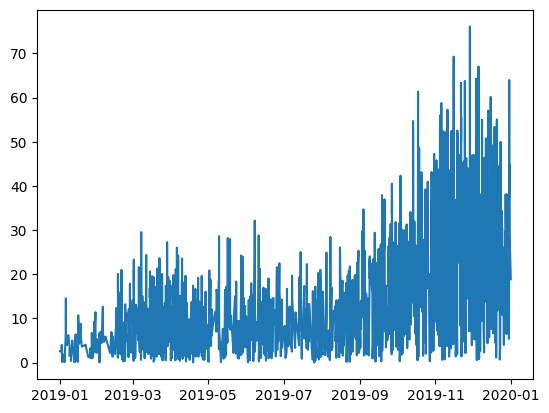

In [21]:
plt.plot(ev_df['Synthetic_7_2kW'])

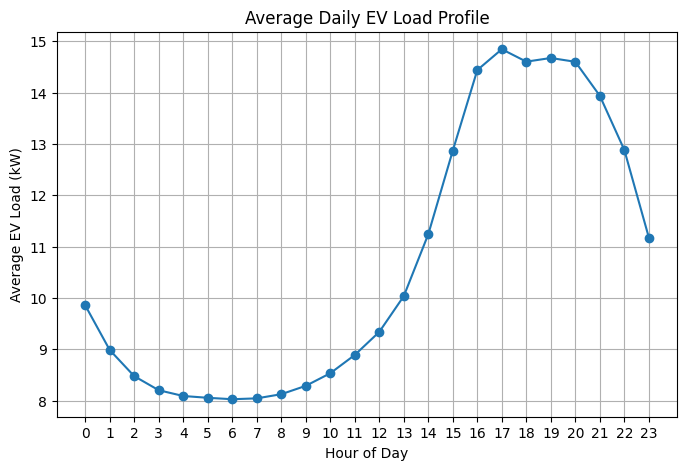

In [22]:
ev_df['hour'] = ev_df.index.hour

# Compute average load per hour
hourly_profile = ev_df.groupby('hour')['Synthetic_7_2kW'].mean()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(hourly_profile.index, hourly_profile.values, marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Average EV Load (kW)')
plt.title('Average Daily EV Load Profile')
plt.grid(True)
plt.xticks(range(0, 24))
plt.show()

### Hosting Capacity

In [25]:
def dynamic_hosting_capacity_network(
    load_bus_t,          # shape (T, n), positive loads
    R, X,                # shape (n, n)
    lhat_new,            # shape (T,)
    host_idx,            # integer index of host bus in ordering
    p0_bar,              # transformer limit
    v0=1.0,
    vmin=0.95,
    pf=0.97,
):
    T, n = load_bus_t.shape

    vmin = np.full(n, float(vmin))
    pf = np.full(n, float(pf))
    eta_bus = np.sqrt(1.0 / (pf ** 2) - 1.0)

    C_res = np.full(T, np.inf, dtype=float)
    C_dyn = np.full(T, np.inf, dtype=float)

    l_agg = load_bus_t.sum(axis=1)

    # Z = R + X diag(eta)
    Z = R + X @ np.diag(eta_bus)

    for t in range(T):
        ell = load_bus_t[t, :]

        # transformer headroom
        headroom_tx = p0_bar - l_agg[t]

        # voltage headroom
        numerator = v0 - vmin - (Z @ ell)
        denominator = Z[:, host_idx]

        valid = denominator > 1e-12
        if np.any(valid):
            headroom_v = np.min(numerator[valid] / denominator[valid])
        else:
            headroom_v = np.inf

        C_res[t] = min(headroom_tx, headroom_v)

        if lhat_new[t] > 1e-12:
            C_dyn[t] = C_res[t] / lhat_new[t]
        else:
            C_dyn[t] = np.inf

    return C_res, C_dyn

In [26]:
def solve_cf_order_stat(C_dyn, C_res, lhat_new, K):
    active_idx = np.where(np.isfinite(C_dyn))[0]
    order = np.argsort(C_dyn[active_idx])
    
    C_star = C_dyn[active_idx][order[K]]
    critical_idx = active_idx[order[:K]]

    u_star = np.zeros_like(lhat_new, dtype=float)
    u_star[critical_idx] = C_res[critical_idx] - C_star * lhat_new[critical_idx]

    return C_star, critical_idx, u_star

In [51]:
# Normalized flexible load profile (EV charing profile in this case)

ev_profile = ev_df["Synthetic_7_2kW"].copy()
ev_profile = ev_profile.reindex(bus_load_pu.index)

# normalize
lhat = ev_profile.to_numpy(dtype=float)
lhat = lhat / lhat.max()

print("Length of lhat:", len(lhat))
print("Min/Max of lhat:", lhat.min(), lhat.max())

# or comment out all above and use the following dummy lhat for testing
# lhat = np.ones(len(bus_load_pu)) # Normalized load

Length of lhat: 35040
Min/Max of lhat: 0.0001314233144959916 1.0


In [55]:
T = len(bus_load)


# candidate interconnection bus
host_bus_number = 13
host_idx = bus_to_idx[host_bus_number]

# limits
p0_bar = 1.0
v0 = 1.0
vmin = 0.95

C_res, C_dyn = dynamic_hosting_capacity_network(
    load_bus_t=bus_load_pu.to_numpy(),
    R=R,
    X=X,
    lhat_new=lhat,
    host_idx=host_idx,
    p0_bar=p0_bar,
    v0=v0,
    vmin=vmin,
    pf=0.9,
)

# no flexibility hosting capacity
C0 = np.min(C_dyn[np.isfinite(C_dyn)])

# with K curtailment interventions
K = 350
C_star, critical_idx, u_star = solve_cf_order_stat(C_dyn, C_res, lhat, K)

print("Residual hosting capacity:", C0*S_base, "KW")
print("Hosting capacity with Curtailment:", C_star*S_base, "KW")
print("Number of curtailed slots:", len(critical_idx))

Residual hosting capacity: 200.70372941202464 KW
Hosting capacity with Curtailment: 383.24491965692334 KW
Number of curtailed slots: 350


### Plotting

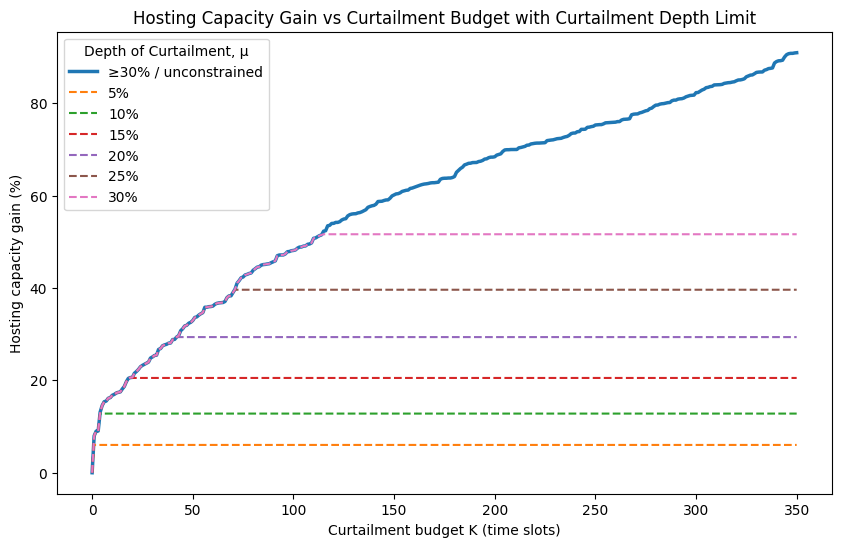

In [56]:
# Active indices where lhat > 0 and C_dyn is finite
active_idx = np.where(np.isfinite(C_dyn))[0]

# Sort active slots by increasing C_dyn
order = np.argsort(C_dyn[active_idx])
sorted_idx = active_idx[order]
sorted_vals = C_dyn[sorted_idx]

T_active = len(sorted_vals)
K_max = 350

# baseline hosting capacity
C0 = sorted_vals[0]
Ks = np.arange(K_max + 1)

# unconstrained curve
Cstars = sorted_vals[Ks]
gains_unconstrained = 100 * (Cstars - C0) / C0

# Constrained Curtailment case
def compute_cstar_with_mu(sorted_idx, sorted_vals, C_res, lhat, Ks, mu):
    Cstars_mu = []

    for K in Ks:
        C_star = sorted_vals[K]
        critical_idx = sorted_idx[:K] # first K slots where curtailment is applied

        if K == 0:
            Cstars_mu.append(C_star)
            continue

        bounds = [C_star]

        # The following logic comes from −u⋆(t)=CK⋆​l^(t)−Cres​(t) and −u⋆(t)≤μCK^* meaning we only can curtail up to μ fraction of the unconstrained curtailment 
        # Then CK⋆​l^(t)−Cres​(t) ≤ μCK^*  => CK⋆​l^(t)−μCK^* ≤ Cres​(t) => CK^*(l^(t)−μ) ≤ Cres​(t) => CK^* ≤ Cres​(t)/(l^(t)−μ)
        # The final equation    C^* ≤ Cres​(t)/(l^(t)−μ)


        for t in critical_idx:
            if lhat[t] > mu:
                bound_t = C_res[t] / (lhat[t] - mu)
                bounds.append(bound_t)


        C_star_mu = min(bounds)
        Cstars_mu.append(C_star_mu)

    return np.array(Cstars_mu)

mu_list = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

plt.figure(figsize=(10, 6))
plt.plot(Ks, gains_unconstrained, linewidth=2.5, label="≥30% / unconstrained")
for mu in mu_list:
    Cstars_mu = compute_cstar_with_mu(sorted_idx, sorted_vals, C_res, lhat, Ks, mu)
    gains_mu = 100 * (Cstars_mu - C0) / C0
    plt.plot(Ks, gains_mu, linestyle="--", label=f"{int(mu*100)}%")

plt.xlabel("Curtailment budget K (time slots)")
plt.ylabel("Hosting capacity gain (%)")
plt.title("Hosting Capacity Gain vs Curtailment Budget with Curtailment Depth Limit")
plt.grid(False)
plt.legend(title="Depth of Curtailment, μ")
plt.show()

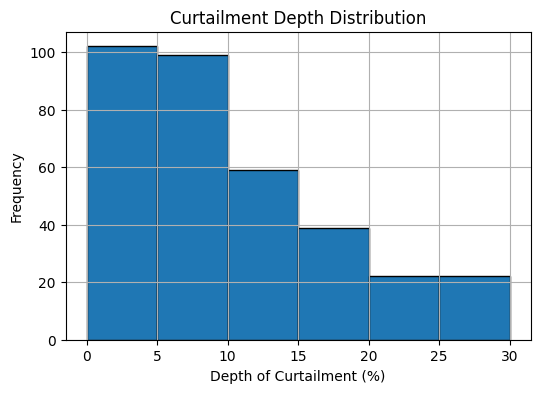

In [57]:
C_star_max= sorted_vals[K_max]
critical_idx = sorted_idx[:K_max]

u_needed = C_star_max * lhat[critical_idx] - C_res[critical_idx]
depth_pct = 100 * u_needed / C_star_max

plt.figure(figsize=(6, 4))
plt.hist(depth_pct, bins=np.arange(0, 31, 5), edgecolor='black')
plt.xlabel("Depth of Curtailment (%)")
plt.ylabel("Frequency")
plt.title("Curtailment Depth Distribution")
plt.grid(True)
plt.show()